In [3]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb

# Load training and scheduling datasets
df_train = pd.read_csv('DataTrain.csv')
df_schedule = pd.read_csv('DataSchedule.csv')

print(f"Training data shape: {df_train.shape}")
print(f"Schedule data shape: {df_schedule.shape}\n")

# Display initial rows and standard descriptive statistics
display(df_train.head())

print("\nDescriptive Statistics (Training Data)")
display(df_train.describe())

Training data shape: (20631, 26)
Schedule data shape: (13096, 26)



,engine_id,cycle,set1,set2,set3,sensor_val1,sensor_val2,sensor_val3,sensor_val4,sensor_val5,...,sensor_val12,sensor_val13,sensor_val14,sensor_val15,sensor_val16,sensor_val17,sensor_val18,sensor_val19,sensor_val20,sensor_val21
0,1,1,100.0,-0.0007,-0.0004,9046.19,521.66,8138.62,1589.70,554.36,...,392,2388.06,1.3,641.82,2388,8.4195,21.61,47.47,14.62,23.4190
1,1,2,100.0,0.0019,-0.0003,9044.07,522.28,8131.49,1591.82,553.75,...,392,2388.04,1.3,642.15,2388,8.4318,21.61,47.49,14.62,23.4236
2,1,3,100.0,-0.0043,0.0003,9052.94,522.42,8133.23,1587.99,554.26,...,390,2388.08,1.3,642.35,2388,8.4178,21.61,47.27,14.62,23.3442
3,1,4,100.0,0.0007,0.0000,9049.48,522.86,8133.83,1582.79,554.45,...,392,2388.11,1.3,642.35,2388,8.3682,21.61,47.13,14.62,23.3739
4,1,5,100.0,-0.0019,-0.0002,9055.15,522.19,8133.80,1582.85,554.00,...,393,2388.06,1.3,642.37,2388,8.4294,21.61,47.28,14.62,23.4044



Descriptive Statistics (Training Data)


,engine_id,cycle,set1,set2,set3,sensor_val1,sensor_val2,sensor_val3,sensor_val4,sensor_val5,...,sensor_val12,sensor_val13,sensor_val14,sensor_val15,sensor_val16,sensor_val17,sensor_val18,sensor_val19,sensor_val20,sensor_val21
count,20631.000000,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,...,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000
mean,51.506568,108.807862,100.0,-0.000009,0.000002,9065.242941,521.413470,8143.752722,1590.523119,553.367711,...,393.210654,2388.096652,1.300000e+00,642.680934,2388.0,8.442146,21.609803,47.541168,1.462000e+01,23.289705
std,29.227633,68.880990,0.0,0.002187,0.000293,22.082880,0.737553,19.076176,6.131150,0.885092,...,1.548763,0.070985,4.660829e-13,0.500053,0.0,0.037505,0.001389,0.267087,3.394700e-12,0.108251
min,1.000000,1.000000,100.0,-0.008700,-0.000600,9021.730000,518.690000,8099.940000,1571.040000,549.850000,...,388.000000,2387.900000,1.300000e+00,641.210000,2388.0,8.324900,21.600000,46.850000,1.462000e+01,22.894200
25%,26.000000,52.000000,100.0,-0.001500,-0.000200,9053.100000,520.960000,8133.245000,1586.260000,552.810000,...,392.000000,2388.050000,1.300000e+00,642.325000,2388.0,8.414900,21.610000,47.350000,1.462000e+01,23.221800
50%,52.000000,104.000000,100.0,0.000000,0.000000,9060.660000,521.480000,8140.540000,1590.100000,553.440000,...,393.000000,2388.090000,1.300000e+00,642.640000,2388.0,8.438900,21.610000,47.510000,1.462000e+01,23.297900
75%,77.000000,156.000000,100.0,0.001500,0.000300,9069.420000,521.950000,8148.310000,1594.380000,554.010000,...,394.000000,2388.140000,1.300000e+00,643.000000,2388.0,8.465600,21.610000,47.700000,1.462000e+01,23.366800
max,100.000000,362.000000,100.0,0.008700,0.000600,9244.590000,523.380000,8293.720000,1616.910000,556.060000,...,400.000000,2388.560000,1.300000e+00,644.530000,2388.0,8.584800,21.610000,48.530000,1.462000e+01,23.618400


In [4]:
# Calculate RUL (Remaining Useful Lifetime)

# Make max_cycles variable
max_cycles = df_train.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.rename(columns={'cycle': 'max_cycle'}, inplace=True)
df_train = df_train.merge(max_cycles, on='engine_id', how='left')

# Calculate RUL: Max Cycle - Current Cycle
df_train['RUL'] = df_train['max_cycle'] - df_train['cycle']
df_train.drop(columns=['max_cycle'], inplace=True)

# Apply Piece-wise Linear RUL (Clipping)
# Cap the maximum RUL at 130. Early in an engine's life, degradation is negligible.
# Forcing the model to predict exact high RULs for healthy engines introduces unnecessary error.
MAX_RUL = 130
df_train['RUL'] = df_train['RUL'].clip(upper=MAX_RUL)

# Verify it worked by looking at the last few cycles of engine 1
print("Checking the end of Engine 1's life:")
display(df_train[df_train['engine_id'] == 1][['engine_id', 'cycle', 'RUL']].tail())

Checking the end of Engine 1's life:


,engine_id,cycle,RUL
187,1,188,4
188,1,189,3
189,1,190,2
190,1,191,1
191,1,192,0


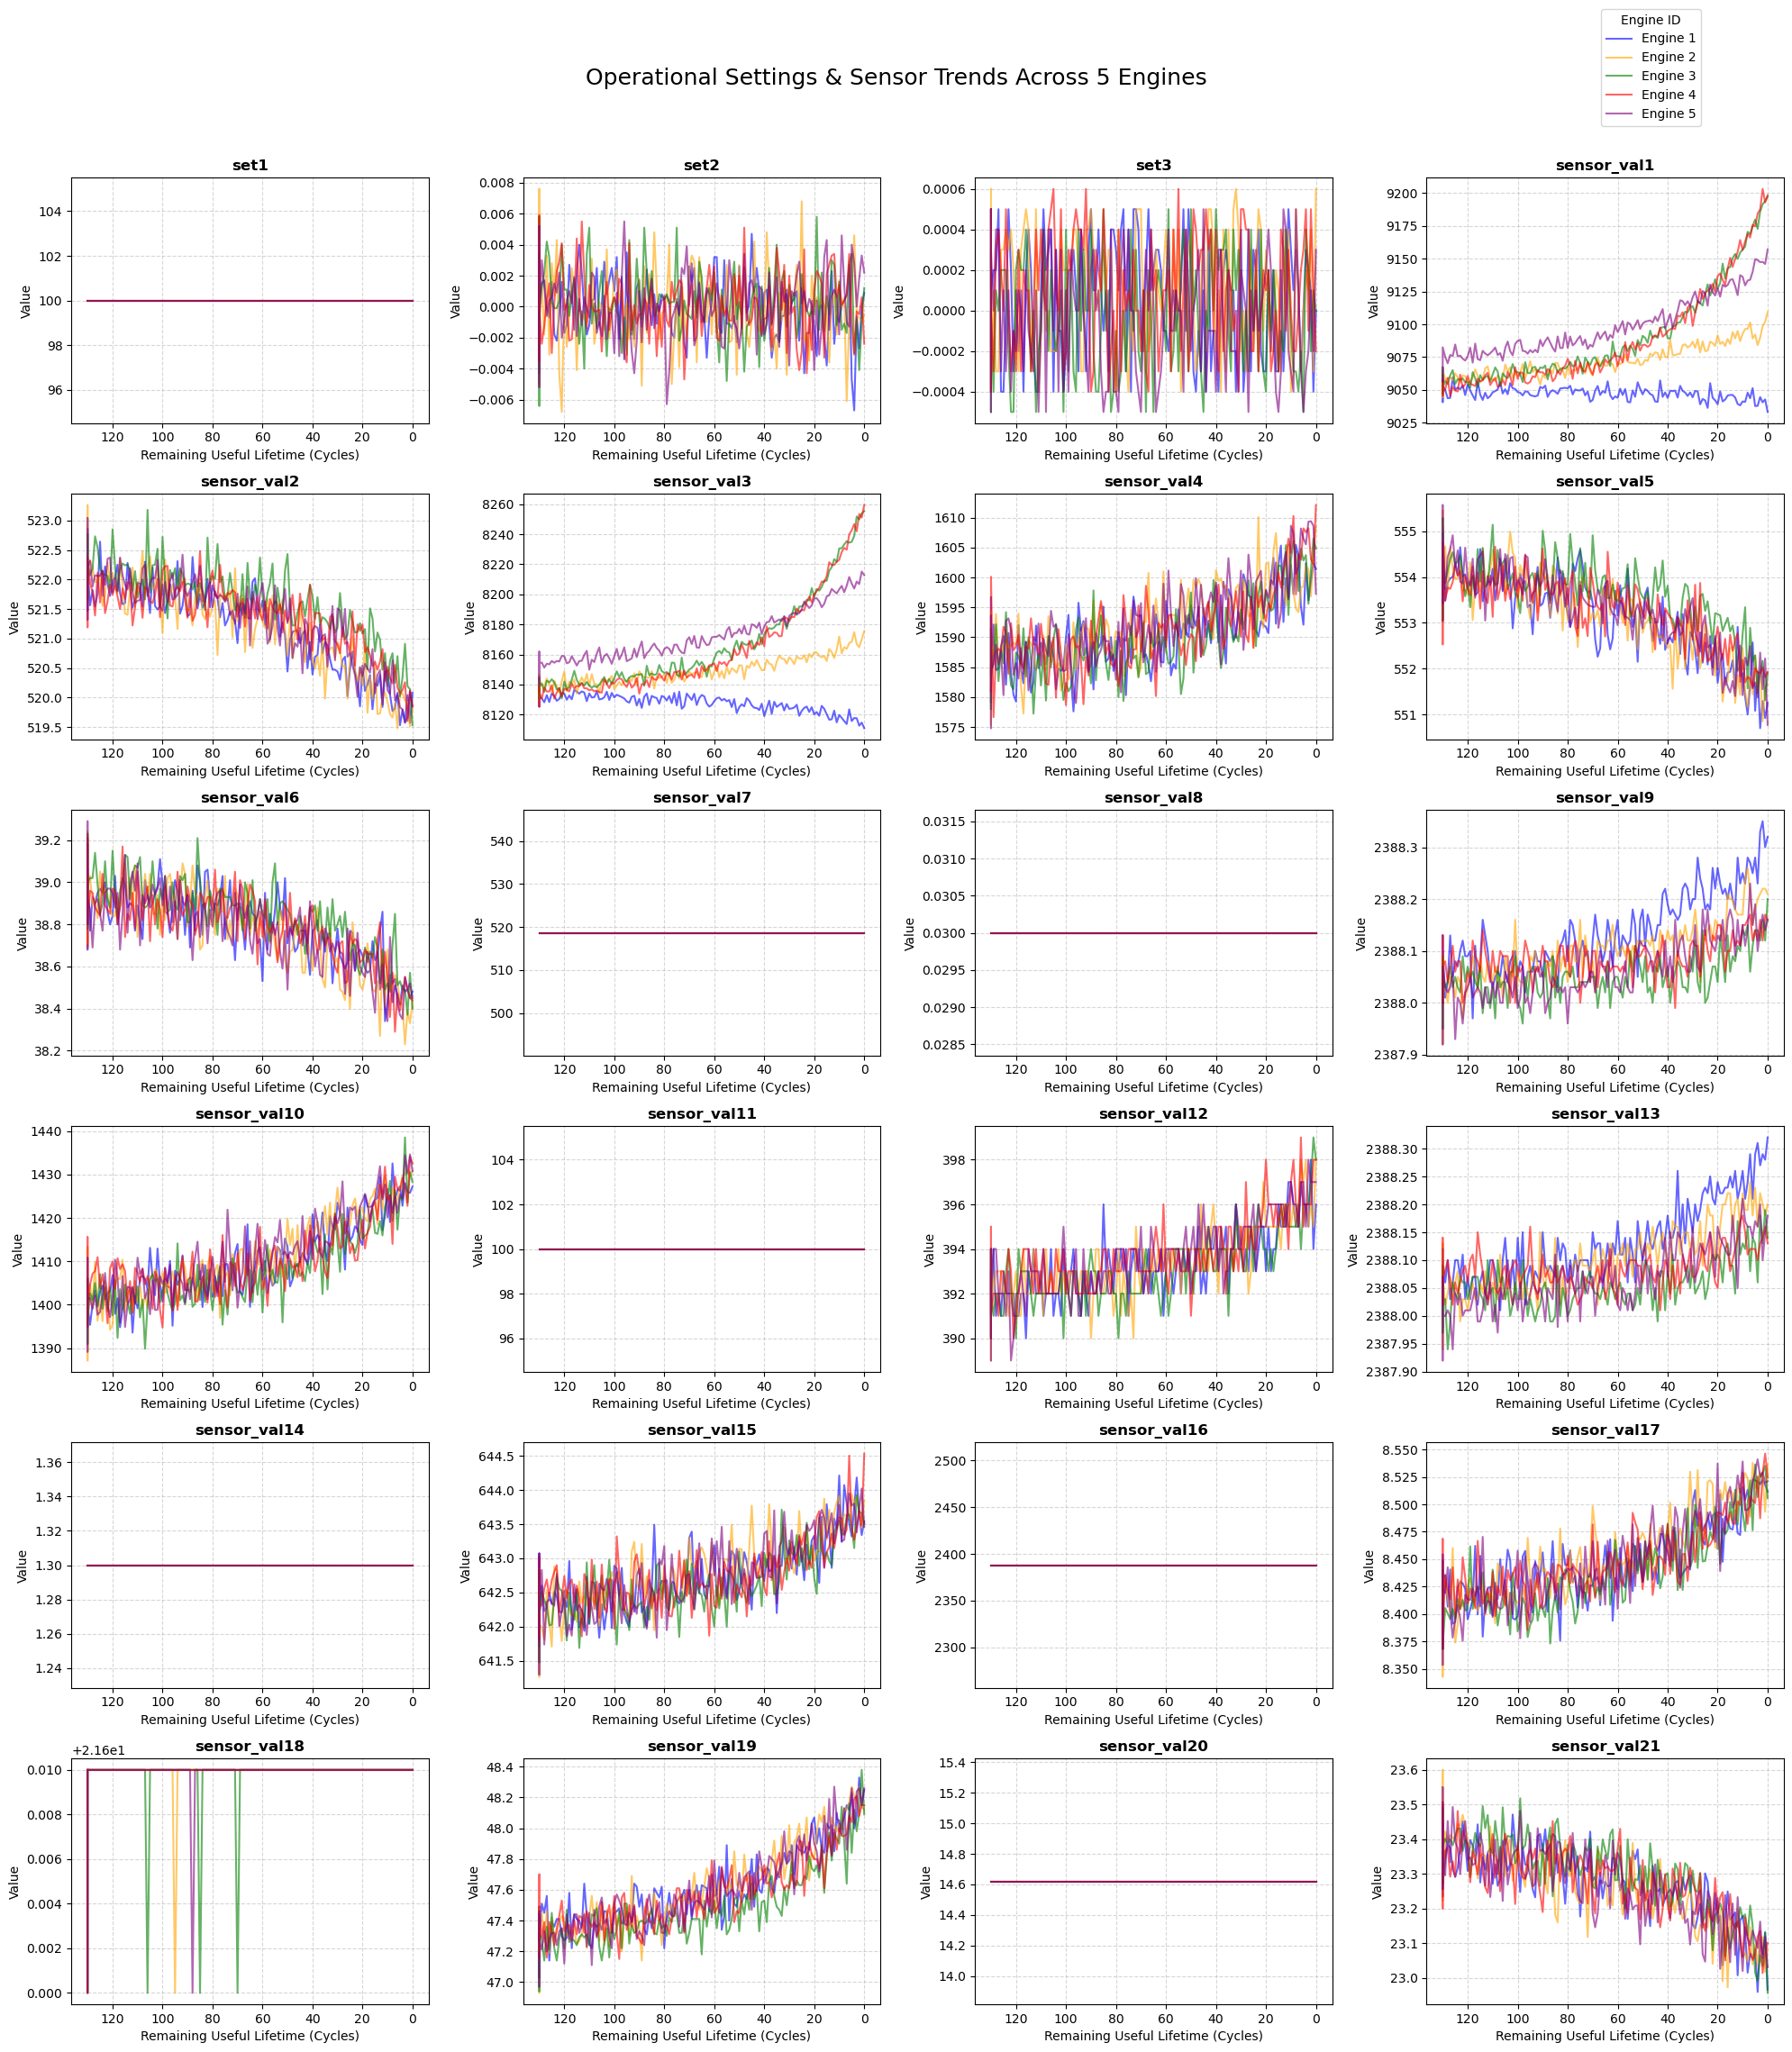

In [5]:
# Sample the first 5 engines to verify global degradation trends
engines_to_plot = [1, 2, 3, 4, 5]
features_to_plot = ['set1', 'set2', 'set3'] + [f'sensor_val{i}' for i in range(1, 22)]

# Initialize a 6x4 plotting grid
fig, axes = plt.subplots(6, 4, figsize=(20, 24))
fig.suptitle('Operational Settings & Sensor Trends Across 5 Engines', fontsize=18, y=0.92)

axes = axes.flatten()
colors = ['blue', 'orange', 'green', 'red', 'purple']

for i, feature in enumerate(features_to_plot):
    ax = axes[i]

    # Overlay line plots for each sampled engine
    for engine_id, color in zip(engines_to_plot, colors):
        engine_data = df_train[df_train['engine_id'] == engine_id]
        # Plotting against RUL standardizes the failure point (0) on the x-axis
        ax.plot(engine_data['RUL'], engine_data[feature], color=color, alpha=0.6, label=f'Engine {engine_id}')

    ax.set_title(feature, fontweight='bold')
    ax.set_xlabel('Remaining Useful Lifetime (Cycles)')
    ax.set_ylabel('Value')
    ax.invert_xaxis() # Countdown to failure
    ax.grid(True, linestyle='--', alpha=0.5)

# Extract legend handles from the first subplot and apply figure-wide
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.95, 0.95), title="Engine ID")

plt.tight_layout(rect=[0, 0, 1, 0.9])

# Export visualization for reporting
plt.savefig('multi_engine_sensor_trends.png', bbox_inches='tight', dpi=300)
plt.show()

In [6]:
# Drop features identified as static/non-informative via visual analysis
useless_features = ['set1', 'sensor_val7','sensor_val8', 'sensor_val11','sensor_val14', 'sensor_val16', 'sensor_val20']
df_train.drop(columns=useless_features, inplace=True, errors='ignore')
df_schedule.drop(columns=useless_features, inplace=True, errors='ignore')

# Identify remaining operational columns for engineering
useful_cols = [col for col in df_train.columns if 'sensor' in col or 'set' in col]

# Generate rolling averages to smooth sensor noise (Window = 10 cycles)
window_size = 10

for col in useful_cols:
    df_train[f'{col}_roll_mean'] = df_train.groupby('engine_id')[col].transform(lambda x: x.rolling(window_size, min_periods=1).mean())
    df_schedule[f'{col}_roll_mean'] = df_schedule.groupby('engine_id')[col].transform(lambda x: x.rolling(window_size, min_periods=1).mean())

print(f"Feature engineering complete. Current training matrix shape: {df_train.shape}")

Feature engineering complete. Current training matrix shape: (20631, 37)


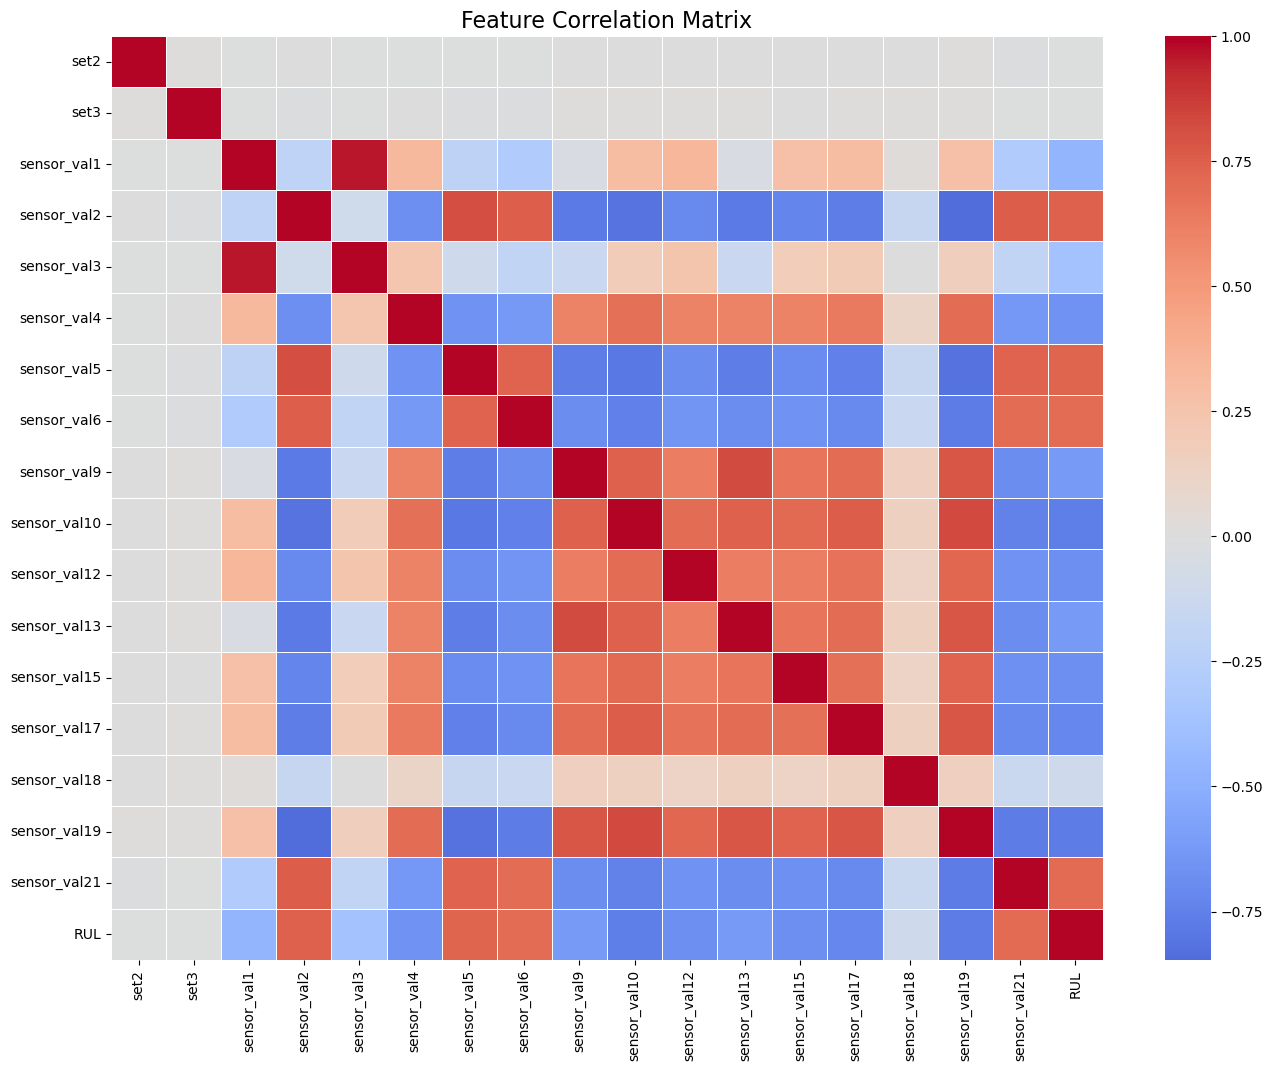

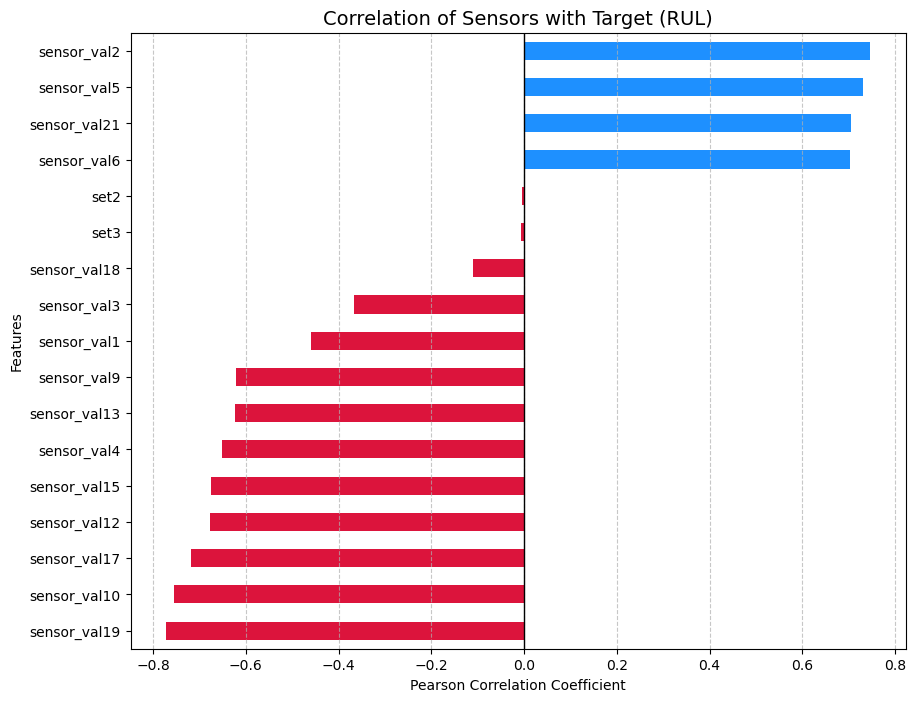

In [7]:
# Evaluate the linear relationship between remaining features and RUL
columns_for_corr = useful_cols + ['RUL']
corr_matrix = df_train[columns_for_corr].corr()

# Plot 1: Feature Multicollinearity Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

# Plot 2: Feature Importance (Correlation with RUL)
plt.figure(figsize=(10, 8))
rul_correlations = corr_matrix['RUL'].drop('RUL').sort_values()
rul_correlations.plot(kind='barh', color=np.where(rul_correlations < 0, 'crimson', 'dodgerblue'))
plt.title('Correlation of Sensors with Target (RUL)', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.axvline(x=0, color='black', linewidth=1)
plt.savefig('rul_correlation_bar_chart.png', bbox_inches='tight', dpi=300)
plt.show()

In [8]:
# Set an absolute correlation threshold to filter out weak predictors
CORR_THRESHOLD = 0.4

# Select features that meet the absolute correlation threshold
strong_features = rul_correlations[abs(rul_correlations) >= CORR_THRESHOLD].index.tolist()

# Update the final feature list to use the engineered rolling mean versions
final_features = [f"{feature}_roll_mean" for feature in strong_features if 'sensor' in feature or 'set' in feature]

print(f"Features retained after correlation thresholding (|r| >= {CORR_THRESHOLD}):")
for feature in final_features:
    print(f" - {feature}")

# Isolate the final independent (X) and dependent (y) variables for modeling
X = df_train[final_features]
y = df_train['RUL']

Features retained after correlation thresholding (|r| >= 0.4):
 - sensor_val19_roll_mean
 - sensor_val10_roll_mean
 - sensor_val17_roll_mean
 - sensor_val12_roll_mean
 - sensor_val15_roll_mean
 - sensor_val4_roll_mean
 - sensor_val13_roll_mean
 - sensor_val9_roll_mean
 - sensor_val1_roll_mean
 - sensor_val6_roll_mean
 - sensor_val21_roll_mean
 - sensor_val5_roll_mean
 - sensor_val2_roll_mean


In [9]:
from sklearn.model_selection import RandomizedSearchCV

# 80/20 train-test split for final holdout validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples\n")

# Initialize the baseline XGBoost Regressor
base_xgb = xgb.XGBRegressor(random_state=42, n_jobs=-1)

# Define the hyperparameter search space
param_distributions = {
    'max_depth': [3, 4, 5, 6],  # Tree complexity
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size
    'n_estimators': [50, 100, 150, 200],  # Number of trees
    'subsample': [0.7, 0.8, 0.9, 1.0],  # Row sampling
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],  # Feature sampling
    'reg_alpha': [0, 0.1, 0.5, 1.0],  # L1 Regularization
    'reg_lambda': [0.5, 1.0, 1.5, 2.0]  # L2 Regularization
}

# Set up Randomized Search (evaluating 20 random parameter combinations)
random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter optimization")
random_search.fit(X_train, y_train)

# Extract the optimal model found during the search
xgb_model = random_search.best_estimator_

print("\nOptimal Hyperparameters Found")
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")

# The best cross-validation RMSE achieved during the search
best_cv_rmse = -random_search.best_score_
print(f"\nBest 5-Fold CV RMSE: {best_cv_rmse:.2f} cycles")

#Final evaluations
# Generate predictions on the 20% unseen test set using the tuned model
y_pred = xgb_model.predict(X_test)

# Calculate final evaluation metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)

print("Final Test Set Performance")
print(f"Test RMSE: {test_rmse:.2f} cycles")
print(f"Test MAE:  {test_mae:.2f} cycles")

Training set: 16504 samples
Testing set: 4127 samples

Starting hyperparameter optimization
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Optimal Hyperparameters Found
subsample: 1.0
reg_lambda: 1.0
reg_alpha: 0.1
n_estimators: 150
max_depth: 5
learning_rate: 0.2
colsample_bytree: 1.0

Best 5-Fold CV RMSE: 15.39 cycles
Final Test Set Performance
Test RMSE: 15.54 cycles
Test MAE:  10.79 cycles


In [10]:
from scipy import stats

# Extract the 'current' state of each engine in the schedule dataset
# By grouping by engine_id and taking the last row, we get the final recorded cycle
df_schedule_latest = df_schedule.groupby('engine_id').last().reset_index()

# Ensure we use the exact same engineered features we used for training
X_schedule = df_schedule_latest[final_features]

# Predict using our tuned XGBoost model
predictions = np.round(xgb_model.predict(X_schedule)).astype(int)

# Create dataframe with our predicted RUL values
our_predictions_df = pd.DataFrame({
    'engine_id': df_schedule_latest['engine_id'],
    'RUL': predictions
})

# Save predictions for Task 2.2 and 2.3
our_predictions_df.to_csv('our_rul_predictions.csv', index=False)

print("Our RUL predictions exported successfully.")
display(our_predictions_df.head())

Our RUL predictions exported successfully.


,engine_id,RUL
0,1,125
1,2,127
2,3,54
3,4,122
4,5,124


In [11]:
# Load the consultancy predictions
df_consultancy = pd.read_csv('RUL_consultancy_predictions_A3.csv', sep=';')
df_consultancy.head()
consultancy_raw = df_consultancy['RUL'].values

# Standardize the baseline (Clipping)
# Clip the consultancy predictions to my MAX_RUL (130) for a fair comparison
consultancy_clipped = np.clip(consultancy_raw, a_min=None, a_max=MAX_RUL)

# Check to make sure the lengths match before testing (both should be 100)
if len(predictions) != len(consultancy_clipped):
    print(f"Warning: Length mismatch. My: {len(your_predictions)}, Consultancy: {len(consultancy_clipped)}")

# Perform statistical testing
stat, p_value = stats.wilcoxon(predictions, consultancy_clipped)

print("Prediction Comparison Results")
print(f"Mean Prediction (My):          {predictions.mean():.2f} cycles")
print(f"Mean Prediction (Consultancy): {consultancy_clipped.mean():.2f} cycles")
print(f"Wilcoxon Test p-value:         {p_value:.5e}")

if p_value < 0.05:
    print("\nConclusion: There is a statistically significant difference between my predictions and the consultancy's.")
else:
    print("\nConclusion: There is no statistically significant difference between the predictions.")

Prediction Comparison Results
Mean Prediction (My):          80.39 cycles
Mean Prediction (Consultancy): 79.48 cycles
Wilcoxon Test p-value:         8.32699e-01

Conclusion: There is no statistically significant difference between the predictions.


## Assignment 2

In [12]:
import pandas as pd
import random
random.seed(42)

In [13]:
df = pd.read_csv("DataSchedule.csv")
RUL = pd.read_csv("RUL_consultancy_predictions_A3.csv", sep=";")

## Genetic Algorithm

`load_and_prepare_rul_predictions`: loads a CSV file and returns a dictionary of engine IDs mapped to RUL values.

`compute_safety_due_dates`: computes the safety due date ts = t1 + RUL − 1 for each engine.

`get_engines_in_horizon`: returns all engines whose safety due date is within the planning horizon.

`get_maintenance_duration`: returns the maintenance duration for an engine based on its ID and team type.

`get_team_type`: returns whether a team is type A or type B.

`compute_penalty_cost`: computes the penalty cost for an engine based on how late it is maintained or if it is not maintained.

`create_individual`: creates a random schedule assigning some engines to teams and start days.

`initialize_population`: generates an initial population of random individuals.

`is_feasible`: checks whether a schedule violates constraints such as overlapping jobs or exceeding the horizon.

`compute_total_fitness`: calculates the total penalty cost of a schedule, where lower cost means better fitness.

`parent_selection`: selects parents using tournament selection by choosing the best individual from each sampled group.

`repair_individual`: fixes scheduling conflicts by shifting or removing jobs so that no team has overlapping tasks.

`crossover`: performs single‑point crossover between two parents and repairs the resulting children.

`mutate`: applies a random mutation to one engine and repairs the resulting schedule.


**(a) What does an individual look like, representing a complete maintenance schedule?**

An individual is a fixed-length list of 100 slots, one per engine. Each slot is either `None` (engine not scheduled for maintenance) or a `(team_id, start_day)` tuple. The index in the list corresponds to `engine_id - 1`, so `individual[j]` always refers to engine `j+1`.

**(b) What is your selection strategy (to select parents)?**

Tournament selection: sample k=3 random individuals from the population, select the one with the lowest (best) fitness. Repeat until the desired parent pool size is reached.

**(c) What is your crossover method?**

Single-point crossover on the fixed-length list. A random crossover point is chosen in engines [1, 99]. Child1 takes slots [0:point] from parent1 and [point:] from parent2. Child2 takes the reverse. Because each slot is independent (no duplicates engines possible) only team-overlap conflicts need repair.

**(d) What is your mutation method?**

One of three mutation operators is applied randomly to one engine slot per mutation:
1. **Shift start day**: move the start day of a scheduled engine by a small random amount.
2. **Swap team**: reassign the engine to a different randomly chosen team.
3. **Toggle schedule**: add an unscheduled engine to the schedule, or remove a scheduled one.

**(e) How do you deal with infeasible individuals after crossover and/or mutation?**

A `repair_individual` function is called after every crossover and mutation. It resolves team scheduling conflicts by iterating over each team's jobs sorted by start day, and pushing any overlapping job to start immediately after the previous one ends. Jobs that cannot fit within T are removed (set to None).

**(f) Hyperparameters and design choices?**
population_size

parent_size

tournament_size

mutation_operator (implicit: shift / swap_team / toggle)

crossover_point 

initial_schedule_probability (the 30% in create_individual)

shift_range (the ±3 days in mutation)

In [14]:
import random
import pandas as pd
import time
import copy
import numpy as np
import matplotlib.pyplot as plt

M = 100        # total number of engines
G = 4          # total number of teams
T = 30         # planning horizon in days
t1 = 1         # current day
TEAMS = ["T1", "T2", "T3", "T4"]

def load_and_prepare_rul_predictions(filepath):
    """
    Load RUL predictions from a CSV file and return a dictionary mapping
    engine_id to predicted RUL value (rounded to integer).
    """
    df = pd.read_csv(filepath, sep=";")
    df["RUL"] = df["RUL"].astype(int)
    rul_dict = dict(zip(df["id"], df["RUL"]))
    return rul_dict

def load_and_prepare_rul_predictions_with_comma(filepath):
    """
    Load RUL predictions from a CSV file and return a dictionary mapping
    engine_id to predicted RUL value (rounded to integer).
    """
    df = pd.read_csv(filepath, sep=",")
    df["RUL"] = df["RUL"].astype(int)
    rul_dict = dict(zip(df["engine_id"], df["RUL"]))
    return rul_dict


def compute_safety_due_dates(rul_predictions, t1=1):
    """
    Compute the safety due date ts = t1 + RUL - 1 for each engine.
    Returns a dict mapping engine_id -> safety due date.
    """
    safety_due_dates = {}
    for engine_id, rul in rul_predictions.items():
        safety_due_dates[engine_id] = t1 + rul - 1
    return safety_due_dates


def get_engines_in_horizon(safety_due_dates, T=30):
    """
    Return the list of engine_ids whose safety due date falls within
    the planning horizon (ts <= T).
    """
    engines_in_horizon = [
        engine_id for engine_id, ts in safety_due_dates.items() if ts <= T
    ]
    return engines_in_horizon


def get_maintenance_duration(engine_id, team_type):
    """
    Return maintenance duration (days) for a given engine and team type (A or B).
    Based on mu_A and mu_B rules from the assignment.
    """
    if engine_id <= 20:
        mu_A = 5
    elif engine_id <= 55:
        mu_A = 3
    elif engine_id <= 80:
        mu_A = 4
    else:
        mu_A = 5

    if engine_id <= 25:
        mu_B = mu_A - 1
    elif engine_id <= 70:
        mu_B = mu_A + 3
    else:
        mu_B = mu_A + 2

    return mu_A if team_type == "A" else mu_B


def get_team_type(team_id):
    """Return 'A' for teams T1/T3 and 'B' for teams T2/T4."""
    return "A" if team_id in ["T1", "T3"] else "B"


def compute_penalty_cost(engine_id, maintenance_end_day, safety_due_date, T=30):
    """
    Compute the total penalty cost for an engine.
    - If maintenance_end_day is None: engine is unmaintained, penalise every
      day after ts up to T.
    - Otherwise: penalise every day after ts up to maintenance_end_day.
    Daily cost = cj * (t - ts)^2, capped at 250.
    """
    if engine_id <= 25:
        cj = 4
    elif engine_id <= 45:
        cj = 2
    elif engine_id <= 75:
        cj = 5
    else:
        cj = 6

    total_cost = 0
    last_late_day = T if maintenance_end_day is None else maintenance_end_day

    for t in range(safety_due_date + 1, last_late_day + 1):
        daily_cost = cj * (t - safety_due_date) ** 2
        total_cost += min(daily_cost, 250)

    return total_cost


def create_individual(engines_in_horizon, T=30):
    """
    Create a random individual as a fixed-length list of M slots.
    Only engines in the horizon are candidates for scheduling.
    Each candidate is scheduled with 30% probability.
    """
    individual = [None] * M
    horizon_set = set(engines_in_horizon)

    for engine_id in range(1, M + 1):
        if engine_id not in horizon_set:
            continue

        if random.random() > 0.30:
            continue

        team_id = random.choice(TEAMS)
        team_type = get_team_type(team_id)
        duration = get_maintenance_duration(engine_id, team_type)

        latest_start = T - duration + 1
        if latest_start < 1:
            continue

        start_day = random.randint(1, latest_start)

        individual[engine_id - 1] = (team_id, start_day)

    return individual



def initialize_population(engines_in_horizon, population_size, T=30):
    """
    Generate an initial population of fixed-length individuals.
    Returns a list of population_size individuals.
    """
    return [create_individual(engines_in_horizon, T) for _ in range(population_size)]

def is_feasible(individual, T=30):
    """
    Check that an individual satisfies all constraints:
    - No team has overlapping jobs.
    - All jobs complete within the planning horizon T.
    Duplicate engines are impossible by design (fixed-length list).
    Returns True if feasible, False otherwise.
    """
    team_schedules = {team: [] for team in TEAMS}

    for engine_id in range(1, M + 1):
        slot = individual[engine_id - 1]
        if slot is None:
            continue

        team_id, start_day = slot
        team_type = get_team_type(team_id)
        duration = get_maintenance_duration(engine_id, team_type)
        end_day = start_day + duration - 1  

        if end_day > T:
            return False

        for s, e in team_schedules[team_id]:
            if start_day <= e and end_day >= s:
                return False

        team_schedules[team_id].append((start_day, end_day))

    return True



def compute_total_fitness(individual, safety_due_dates, engines_in_horizon, T=30):
    """
    Compute the total penalty cost for a given individual.
    For each engine in the horizon:
    - If scheduled: penalise based on maintenance end day vs safety due date.
    - If not scheduled: penalise as if unmaintained for the full horizon.
    Lower fitness = better.
    """
    total_cost = 0

    for engine_id in engines_in_horizon:
        slot = individual[engine_id - 1]
        ts = safety_due_dates[engine_id]

        if slot is not None:
            team_id, start_day = slot
            team_type = get_team_type(team_id)
            duration = get_maintenance_duration(engine_id, team_type)
            end_day = start_day + duration - 1  

            total_cost += compute_penalty_cost(engine_id, end_day, ts, T)
        else:
            total_cost += compute_penalty_cost(engine_id, None, ts, T)

    return total_cost



def parent_selection(population, fitnesses, parent_size, tournament_size=3):
    """
    Tournament selection: randomly sample tournament_size individuals,
    keep the one with the lowest fitness. Repeat until parent_size winners
    are collected. Selection is with replacement.
    """
    winners = []
    for _ in range(parent_size):
        idxs = random.sample(range(len(population)), tournament_size)
        best = min(idxs, key=lambda i: fitnesses[i])
        winners.append(population[best])
    return winners


def repair_individual(individual, T=30):
    """
    Repair schedule:
    - Sort jobs per team
    - Push overlapping jobs forward
    - Remove jobs that no longer fit
    """
    team_jobs = {team: [] for team in TEAMS}

    # Collect jobs
    for engine_id in range(1, M + 1):
        slot = individual[engine_id - 1]
        if slot is not None:
            team_id, start_day = slot
            team_jobs[team_id].append(engine_id)

    # Repair per team
    for team_id, job_ids in team_jobs.items():
        job_ids.sort(key=lambda eid: individual[eid - 1][1])
        earliest_available = 1

        for engine_id in job_ids:
            team_id_slot, start_day = individual[engine_id - 1]
            team_type = get_team_type(team_id_slot)
            duration = get_maintenance_duration(engine_id, team_type)

            repaired_start = max(start_day, earliest_available)
            repaired_end = repaired_start + duration - 1

            if repaired_end > T:
                individual[engine_id - 1] = None
            else:
                individual[engine_id - 1] = (team_id_slot, repaired_start)
                earliest_available = repaired_end + 1

    return individual


def crossover(parent1, parent2, T=30):
    cp = random.randint(1, M - 1)

    child1 = copy.deepcopy(parent1[:cp] + parent2[cp:])
    child2 = copy.deepcopy(parent2[:cp] + parent1[cp:])

    return repair_individual(child1, T), repair_individual(child2, T)



def mutate(individual, engines_in_horizon, T=30):
    """
    Apply one of three mutation operators to a randomly selected engine slot:
    1. Shift start day: move start day by a small random offset (+/- 3 days).
    2. Swap team: reassign the engine to a different randomly chosen team.
    3. Toggle schedule: add an unscheduled engine or remove a scheduled one.
    The individual is repaired after mutation to restore feasibility.
    """
    individual = copy.deepcopy(individual)
    engine_id = random.choice(engines_in_horizon)
    slot = individual[engine_id - 1]

    operator = random.choice(["shift", "swap_team", "toggle"])

    if operator == "shift" and slot is not None:
        team_id, start_day = slot
        team_type = get_team_type(team_id)
        duration = get_maintenance_duration(engine_id, team_type)
        latest_start = T - duration + 1

        shift = random.randint(-3, 3)
        new_start = max(1, min(latest_start, start_day + shift))

        individual[engine_id - 1] = (team_id, new_start)

    elif operator == "swap_team" and slot is not None:
        old_team, start_day = slot
        new_team = random.choice([t for t in TEAMS if t != old_team])
        new_team_type = get_team_type(new_team)

        duration = get_maintenance_duration(engine_id, new_team_type)
        latest_start = T - duration + 1
        new_start = min(start_day, latest_start)

        individual[engine_id - 1] = (new_team, new_start)

    else:
        if slot is None:
            team_id = random.choice(TEAMS)
            team_type = get_team_type(team_id)
            duration = get_maintenance_duration(engine_id, team_type)
            latest_start = T - duration + 1

            if latest_start >= 1:
                start_day = random.randint(1, latest_start)
                individual[engine_id - 1] = (team_id, start_day)
        else:
            individual[engine_id - 1] = None

    return repair_individual(individual, T)



# testing functions

In [15]:
rul = load_and_prepare_rul_predictions("RUL_consultancy_predictions_A3.csv")
safety = compute_safety_due_dates(rul)
engines = get_engines_in_horizon(safety)

d1 = get_maintenance_duration(10,"A")
d2 = get_maintenance_duration(10,"B")

tt1 = get_team_type("T1")
tt2 = get_team_type("T2")

pc1 = compute_penalty_cost(1,15,safety[1])
pc2 = compute_penalty_cost(2,None,safety[2])

ind = create_individual(engines)
pop = initialize_population(engines,5)

f = is_feasible(ind)

fit = compute_total_fitness(ind,safety,engines)

parents = parent_selection(pop,[compute_total_fitness(i,safety,engines) for i in pop],2)

repaired = repair_individual(ind)

c1,c2 = crossover(pop[0],pop[1])

mut = mutate(ind,engines)

print("rul",rul)
print("safety",safety)
print("engines",engines)
print("durations",d1,d2)
print("team types",tt1,tt2)
print("penalties",pc1,pc2)
print("individual",ind)
print("population size",len(pop))
print("feasible",f)
print("fitness",fit)
print("parents",parents)
print("repaired",repaired)
print("children",c1,c2)
print("mutated",mut)



rul {1: 135, 2: 125, 3: 63, 4: 100, 5: 103, 6: 122, 7: 106, 8: 90, 9: 121, 10: 67, 11: 101, 12: 89, 13: 87, 14: 122, 15: 114, 16: 101, 17: 52, 18: 33, 19: 84, 20: 10, 21: 63, 22: 141, 23: 119, 24: 26, 25: 173, 26: 128, 27: 70, 28: 96, 29: 96, 30: 87, 31: 14, 32: 54, 33: 128, 34: 8, 35: 8, 36: 24, 37: 21, 38: 58, 39: 144, 40: 29, 41: 23, 42: 13, 43: 67, 44: 146, 45: 100, 46: 53, 47: 130, 48: 151, 49: 14, 50: 100, 51: 106, 52: 34, 53: 34, 54: 126, 55: 174, 56: 18, 57: 102, 58: 38, 59: 113, 60: 112, 61: 23, 62: 54, 63: 75, 64: 24, 65: 152, 66: 18, 67: 174, 68: 13, 69: 130, 70: 90, 71: 130, 72: 59, 73: 113, 74: 115, 75: 115, 76: 3, 77: 27, 78: 165, 79: 82, 80: 84, 81: 6, 82: 11, 83: 182, 84: 53, 85: 142, 86: 113, 87: 126, 88: 117, 89: 111, 90: 28, 91: 29, 92: 24, 93: 51, 94: 55, 95: 143, 96: 140, 97: 109, 98: 87, 99: 127, 100: 24}
safety {1: 135, 2: 125, 3: 63, 4: 100, 5: 103, 6: 122, 7: 106, 8: 90, 9: 121, 10: 67, 11: 101, 12: 89, 13: 87, 14: 122, 15: 114, 16: 101, 17: 52, 18: 33, 19: 84,

In [18]:
# ============================================================
# Task 2.2 and 2.3: Run GA experiments and compare RUL sources
# ============================================================

import random
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- GA runner for one experiment ----------

def run_ga_once(
    rul_predictions,
    population_size=80,
    generations=150,
    crossover_probability=0.8,
    mutation_probability=0.3,
    tournament_size=3,
    seed=None
):
    """
    Run the GA once and return:
    - best individual
    - best final fitness
    - best fitness history over generations
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    safety = compute_safety_due_dates(rul_predictions)
    engines = get_engines_in_horizon(safety, T)

    population = initialize_population(engines, population_size, T)
    population = [repair_individual(ind, T) for ind in population]

    fitnesses = [
        compute_total_fitness(ind, safety, engines, T)
        for ind in population
    ]

    best_idx = int(np.argmin(fitnesses))
    best_individual = copy.deepcopy(population[best_idx])
    best_fitness = fitnesses[best_idx]

    best_history = [best_fitness]

    for generation in range(generations):
        parents = parent_selection(
            population,
            fitnesses,
            population_size,
            tournament_size=tournament_size
        )

        new_population = []

        for i in range(0, population_size, 2):
            p1 = parents[i]
            p2 = parents[(i + 1) % population_size]

            if random.random() < crossover_probability:
                c1, c2 = crossover(p1, p2, T)
            else:
                c1, c2 = copy.deepcopy(p1), copy.deepcopy(p2)

            if random.random() < mutation_probability:
                c1 = mutate(c1, engines, T)

            if random.random() < mutation_probability:
                c2 = mutate(c2, engines, T)

            new_population.extend([c1, c2])

        population = new_population[:population_size]

        fitnesses = [
            compute_total_fitness(ind, safety, engines, T)
            for ind in population
        ]

        generation_best_idx = int(np.argmin(fitnesses))
        generation_best_fitness = fitnesses[generation_best_idx]

        if generation_best_fitness < best_fitness:
            best_fitness = generation_best_fitness
            best_individual = copy.deepcopy(population[generation_best_idx])

        best_history.append(best_fitness)

    return best_individual, best_fitness, best_history

In [19]:
# ---------- Run 30 independent GA runs ----------

def run_30_ga_experiments(rul_predictions, label, n_runs=30):
    all_histories = []
    final_costs = []
    best_solutions = []

    for run in range(n_runs):
        best_individual, best_fitness, best_history = run_ga_once(
            rul_predictions=rul_predictions,
            seed=1000 + run
        )

        all_histories.append(best_history)
        final_costs.append(best_fitness)
        best_solutions.append(best_individual)

        print(f"{label} | run {run + 1:02d}/{n_runs} | best cost = {best_fitness}")

    best_run_index = int(np.argmin(final_costs))

    return {
        "label": label,
        "histories": np.array(all_histories),
        "average_best_history": np.mean(np.array(all_histories), axis=0),
        "final_costs": np.array(final_costs),
        "best_solution": best_solutions[best_run_index],
        "best_cost": final_costs[best_run_index],
        "best_run_index": best_run_index
    }

In [20]:
pd.read_csv("our_rul_predictions.csv").head()

,engine_id,RUL
0,1,125
1,2,127
2,3,54
3,4,122
4,5,124


In [21]:
# ---------- Load RUL predictions ----------

# Consultancy predictions
consultancy_rul = load_and_prepare_rul_predictions("RUL_consultancy_predictions_A3.csv")

# Your group's own predictions
# Change this filename if your teammate saved it differently.
our_rul = load_and_prepare_rul_predictions_with_comma("our_rul_predictions.csv")

In [22]:
# ---------- Task 2.2: Run GA with our own RUL predictions ----------

our_results = run_30_ga_experiments(
    rul_predictions=our_rul,
    label="Our XGBoost RUL predictions",
    n_runs=30
)


# ---------- Task 2.3: Run GA with consultancy RUL predictions ----------

consultancy_results = run_30_ga_experiments(
    rul_predictions=consultancy_rul,
    label="Consultancy RUL predictions",
    n_runs=30
)

Our XGBoost RUL predictions | run 01/30 | best cost = 4649
Our XGBoost RUL predictions | run 02/30 | best cost = 2102
Our XGBoost RUL predictions | run 03/30 | best cost = 3240
Our XGBoost RUL predictions | run 04/30 | best cost = 1748
Our XGBoost RUL predictions | run 05/30 | best cost = 1946
Our XGBoost RUL predictions | run 06/30 | best cost = 1278
Our XGBoost RUL predictions | run 07/30 | best cost = 2405
Our XGBoost RUL predictions | run 08/30 | best cost = 2508
Our XGBoost RUL predictions | run 09/30 | best cost = 2697
Our XGBoost RUL predictions | run 10/30 | best cost = 6290
Our XGBoost RUL predictions | run 11/30 | best cost = 1486
Our XGBoost RUL predictions | run 12/30 | best cost = 2881
Our XGBoost RUL predictions | run 13/30 | best cost = 1232
Our XGBoost RUL predictions | run 14/30 | best cost = 1656
Our XGBoost RUL predictions | run 15/30 | best cost = 2960
Our XGBoost RUL predictions | run 16/30 | best cost = 2686
Our XGBoost RUL predictions | run 17/30 | best cost = 28

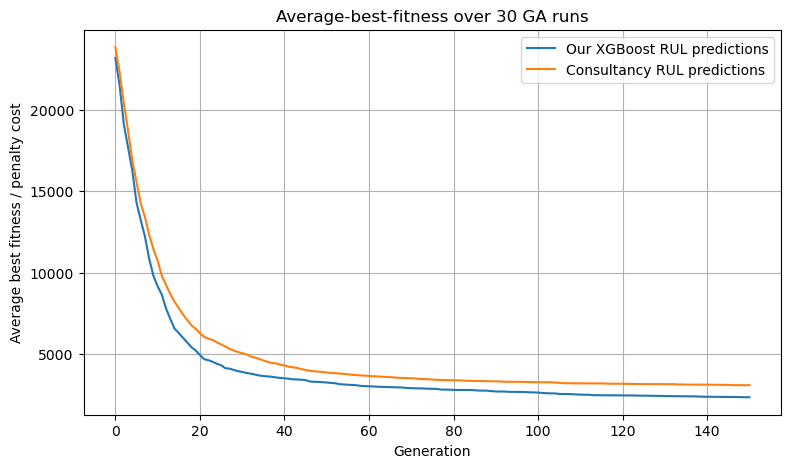

In [23]:
# ---------- Average-best-fitness comparison plot ----------

plt.figure(figsize=(9, 5))

plt.plot(
    our_results["average_best_history"],
    label="Our XGBoost RUL predictions"
)

plt.plot(
    consultancy_results["average_best_history"],
    label="Consultancy RUL predictions"
)

plt.xlabel("Generation")
plt.ylabel("Average best fitness / penalty cost")
plt.title("Average-best-fitness over 30 GA runs")
plt.legend()
plt.grid(True)
plt.savefig('task_2_2_2_3_average_best_fitness_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

In [24]:
# ---------- Summary table ----------

comparison_summary = pd.DataFrame({
    "RUL source": [
        "Our XGBoost predictions",
        "Consultancy predictions"
    ],
    "Best final cost": [
        np.min(our_results["final_costs"]),
        np.min(consultancy_results["final_costs"])
    ],
    "Mean final cost": [
        np.mean(our_results["final_costs"]),
        np.mean(consultancy_results["final_costs"])
    ],
    "Std final cost": [
        np.std(our_results["final_costs"], ddof=1),
        np.std(consultancy_results["final_costs"], ddof=1)
    ]
})

comparison_summary

,RUL source,Best final cost,Mean final cost,Std final cost
0,Our XGBoost predictions,245,2357.766667,1217.979550
1,Consultancy predictions,991,3095.000000,1576.154968


In [ ]:
# ---------- Convert best solution to readable schedule ----------

def solution_to_schedule_df(best_solution, rul_predictions):
    safety = compute_safety_due_dates(rul_predictions)

    rows = []

    for engine_id in range(1, M + 1):
        slot = best_solution[engine_id - 1]
        current_rul = rul_predictions[engine_id]
        ts = safety[engine_id]

        if slot is None:
            cost = compute_penalty_cost(engine_id, None, ts, T)

            rows.append({
                "engine_id": engine_id,
                "RUL": current_rul,
                "safety_due_date": ts,
                "team_id": None,
                "team_type": None,
                "start_date": None,
                "end_date": None,
                "engine_cost": cost
            })

        else:
            team_id, start_day, end_day = slot
            team_type = get_team_type(team_id)
            cost = compute_penalty_cost(engine_id, end_day, ts, T)

            rows.append({
                "engine_id": engine_id,
                "RUL": current_rul,
                "safety_due_date": ts,
                "team_id": team_id,
                "team_type": team_type,
                "start_date": start_day,
                "end_date": end_day,
                "engine_cost": cost
            })

    return pd.DataFrame(rows)


our_best_schedule = solution_to_schedule_df(
    our_results["best_solution"],
    our_rul
)

consultancy_best_schedule = solution_to_schedule_df(
    consultancy_results["best_solution"],
    consultancy_rul
)

our_best_schedule

,engine_id,RUL,safety_due_date,team_id,team_type,start_date,end_date,engine_cost
0,1,125,125,None,None,NaN,NaN,0
1,2,127,127,None,None,NaN,NaN,0
2,3,54,54,None,None,NaN,NaN,0
3,4,122,122,None,None,NaN,NaN,0
4,5,124,124,None,None,NaN,NaN,0
...,...,...,...,...,...,...,...,...
95,96,117,117,None,None,NaN,NaN,0
96,97,84,84,None,None,NaN,NaN,0
97,98,67,67,None,None,NaN,NaN,0
98,99,128,128,None,None,NaN,NaN,0


In [30]:
our_best_schedule.to_csv("task_2_2_best_schedule_our_predictions.csv", index=False)
consultancy_best_schedule.to_csv("task_2_3_best_schedule_consultancy_predictions.csv", index=False)
comparison_summary.to_csv("task_2_3_comparison_summary.csv", index=False)